<a href="https://colab.research.google.com/github/hwasun-zip/RetailRocket/blob/main/RetailRocket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install kagglehub
from google.colab import files
import os
uploaded = files.upload()          # kaggle.json 선택
fname = list(uploaded.keys())[0]
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename(fname, '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('인증 완료')

Saving kaggle (1).json to kaggle (1).json
인증 완료


In [2]:
import kagglehub, glob, os
path = kagglehub.dataset_download('retailrocket/ecommerce-dataset')
print('경로:', path)
for f in sorted(glob.glob(path + '/*.csv')):
    print(' -', os.path.basename(f))

100%|██████████| 291M/291M [00:02<00:00, 152MB/s]

Extracting files...


경로: /root/.cache/kagglehub/datasets/retailrocket/ecommerce-dataset/versions/2
 - category_tree.csv
 - events.csv
 - item_properties_part1.csv
 - item_properties_part2.csv


In [3]:
import pandas as pd
events = pd.read_csv(f'{path}/events.csv')
print(events.shape)
events.head(10)

(2756101, 5)


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN
5,1433224086234,972639,view,22556,NaN
6,1433221923240,810725,view,443030,NaN
7,1433223291897,794181,view,439202,NaN
8,1433220899221,824915,view,428805,NaN
9,1433221204592,339335,view,82389,NaN


In [4]:
import sqlite3
con = sqlite3.connect('retail.db')
events.to_sql('events', con, if_exists='replace', index=False)
def q(sql): return pd.read_sql_query(sql, con)
print('적재 완료:', len(events), '이벤트')

적재 완료: 2756101 이벤트


In [5]:
#이벤트 종류별 개수
q("""
SELECT event, COUNT(*) AS cnt
FROM events
GROUP BY event
ORDER BY cnt DESC
""")

,event,cnt
0,view,2664312
1,addtocart,69332
2,transaction,22457


In [6]:
#방문자 기준 퍼널
q("""
SELECT
  COUNT(DISTINCT CASE WHEN event='view'        THEN visitorid END) AS viewers,
  COUNT(DISTINCT CASE WHEN event='addtocart'   THEN visitorid END) AS carters,
  COUNT(DISTINCT CASE WHEN event='transaction' THEN visitorid END) AS buyers
FROM events
""")

,viewers,carters,buyers
0,1404179,37722,11719


In [7]:
#세션 만들기
q("""
WITH ordered AS (
  SELECT visitorid, event, timestamp,
         LAG(timestamp) OVER (PARTITION BY visitorid ORDER BY timestamp) AS prev_ts
  FROM events
),
flagged AS (
  SELECT *,
         CASE WHEN prev_ts IS NULL OR timestamp - prev_ts > 1800000
              THEN 1 ELSE 0 END AS is_new_session
  FROM ordered
),
sessioned AS (
  SELECT *,
         SUM(is_new_session) OVER (PARTITION BY visitorid ORDER BY timestamp) AS session_seq
  FROM flagged
)
SELECT datetime(timestamp/1000,'unixepoch') AS event_time,
       visitorid, event, session_seq
FROM sessioned
WHERE visitorid = 257597
ORDER BY timestamp
""")

,event_time,visitorid,event,session_seq
0,2015-06-02 05:02:12,257597,view,1
1,2015-06-08 22:00:21,257597,view,2


In [8]:
#세션 테이블 생성
con.executescript("""
DROP TABLE IF EXISTS sessioned;
CREATE TABLE sessioned AS
WITH ordered AS (
  SELECT visitorid, event, timestamp,
         LAG(timestamp) OVER (PARTITION BY visitorid ORDER BY timestamp) AS prev_ts
  FROM events
),
flagged AS (
  SELECT visitorid, event, timestamp,
         CASE WHEN prev_ts IS NULL OR timestamp - prev_ts > 1800000
              THEN 1 ELSE 0 END AS is_new_session
  FROM ordered
)
SELECT visitorid, event, timestamp,
       SUM(is_new_session) OVER (PARTITION BY visitorid ORDER BY timestamp) AS session_seq
FROM flagged;
""")
print('세션 테이블 완성')

세션 테이블 완성


In [9]:
#세션 기본지표
q("""
SELECT
  COUNT(*)                                          AS total_events,
  COUNT(DISTINCT visitorid || '-' || session_seq)   AS total_sessions,
  ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT visitorid || '-' || session_seq), 2) AS events_per_session
FROM sessioned
""")

,total_events,total_sessions,events_per_session
0,2756101,1761675,1.56


In [10]:
#세션 단위 장바구니 이탈
q("""
WITH sess AS (
  SELECT visitorid || '-' || session_seq AS session_id,
         MAX(CASE WHEN event='addtocart'   THEN 1 ELSE 0 END) AS has_cart,
         MAX(CASE WHEN event='transaction' THEN 1 ELSE 0 END) AS has_txn
  FROM sessioned
  GROUP BY session_id
)
SELECT
  SUM(has_cart)                                                   AS cart_sessions,
  SUM(CASE WHEN has_cart=1 AND has_txn=1 THEN 1 ELSE 0 END)       AS cart_and_bought,
  SUM(CASE WHEN has_cart=1 AND has_txn=0 THEN 1 ELSE 0 END)       AS cart_abandoned,
  ROUND(100.0 * SUM(CASE WHEN has_cart=1 AND has_txn=0 THEN 1 ELSE 0 END)
        / SUM(has_cart), 2)                                       AS abandon_rate_pct
FROM sess
""")

,cart_sessions,cart_and_bought,cart_abandoned,abandon_rate_pct
0,43924,11932,31992,72.83


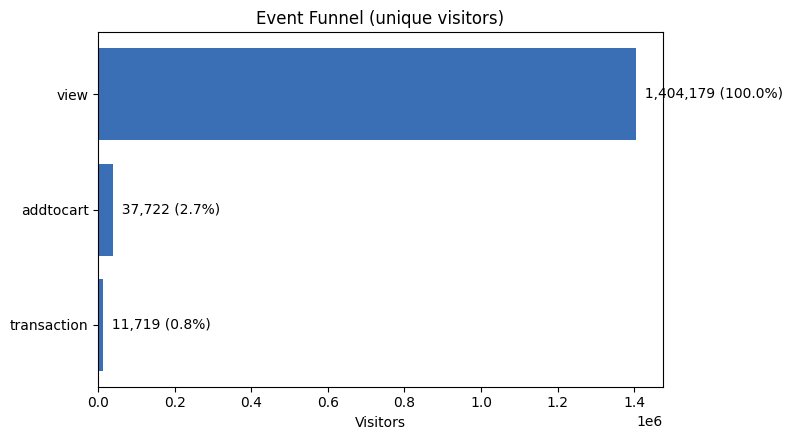

In [11]:
#이벤트 퍼널 차트
import matplotlib.pyplot as plt

stages = ['view', 'addtocart', 'transaction']
vals = [1404179, 37722, 11719]   # 셀 7의 방문자 기준 값
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(stages[::-1], vals[::-1], color='#3b6fb5')
for b, v in zip(bars, vals[::-1]):
    ax.text(b.get_width(), b.get_y()+b.get_height()/2,
            f'  {v:,} ({v/vals[0]*100:.1f}%)', va='center')
ax.set_title('Event Funnel (unique visitors)'); ax.set_xlabel('Visitors')
plt.tight_layout(); plt.savefig('event_funnel.png', dpi=120); plt.show()